In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

# Pre-processing

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


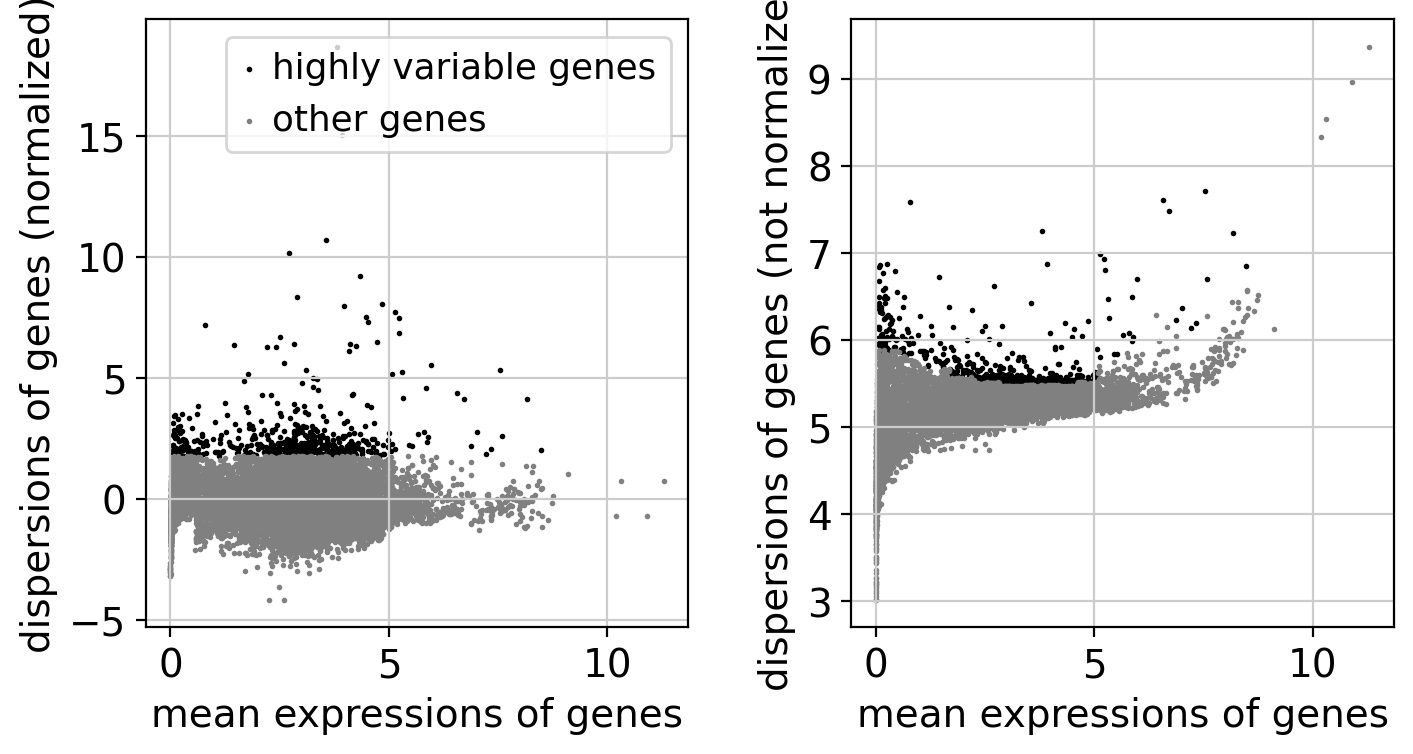

there are 500 hvgs


In [2]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
avis1 = avis.copy()

In [3]:
# > lymph node
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
avis2 = avis.copy()
# add necessary attributes from metadata
avis2.obs['sample_id'] = 'sample'
avis2.obsm['spatial'] = avis2.obs[['imagerow','imagecol']].values

In [4]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis1 = avis1[:, genes].copy()
avis2 = avis2[:, genes].copy()

# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.write_h5ad('../celcomen/data/preproc_spleen.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.write_h5ad('../celcomen/data/preproc_lymphnode.h5ad')

# Run inference module to learn intra- and inter-cellular gene-gene forces

In [5]:
# load model
from celcomen.models.celcomen import celcomen

from celcomen.training_plan.train import train
from celcomen.datareaders.datareader import get_dataset_loaders

from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [6]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_lymphnode.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 500], edge_index=[2, 0], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 500], edge_index=[2, 0], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 500], edge_index=[2, 0], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 500], edge_index=[2, 0], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 500], edge_index=[2, 0], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



### Select the hyperparameters of the model.
zmft_scalar should be the highest value in the range (0,1) such that the loss can be stably minimized. 
n_neighbors should be selected based on what disentanglement we want to achieve in the data. n_neighbors=6 targets disentanglement between intracellular and intercellular forces of short range.

In [33]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-6
zmft_scalar = 1e-1
seed = 0
epochs = 50

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|███████████████████████████████████████████| 50/50 [00:15<00:00,  3.30it/s]


In [30]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-10
zmft_scalar = 1e-1
seed = 0
epochs = 50

# instantiate models on cpu
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model2.to('cpu')
# train the models
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|███████████████████████████████████████████| 50/50 [00:07<00:00,  6.90it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

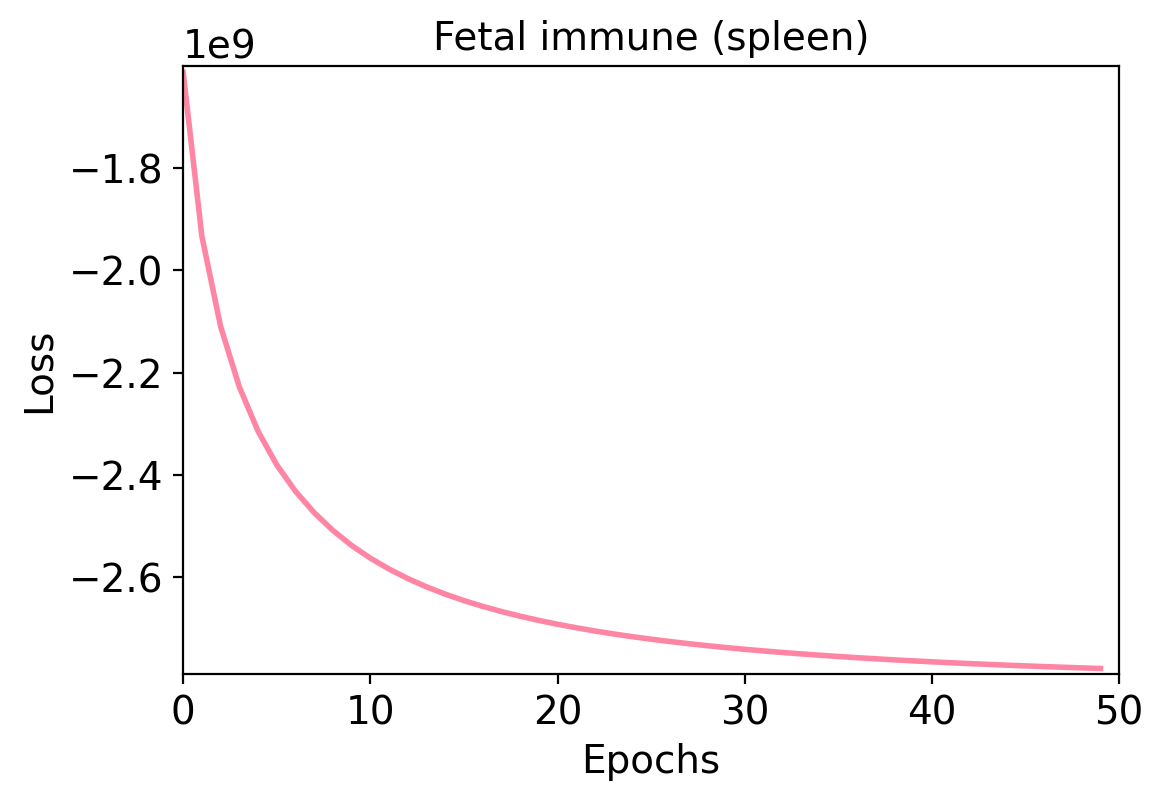

In [34]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, 50)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult immune (lymph node)')]

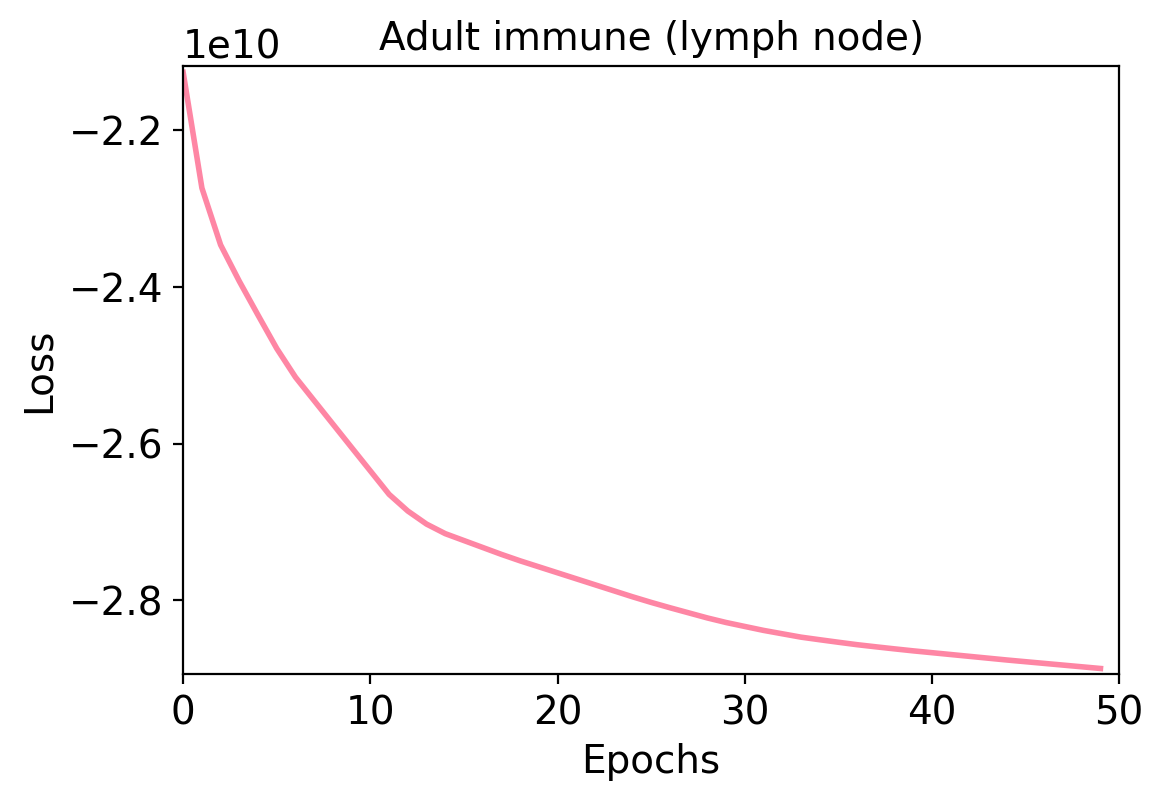

In [35]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, 50)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')

### modulate z-mft

100%|███████████████████████████████████████████| 50/50 [00:14<00:00,  3.35it/s]


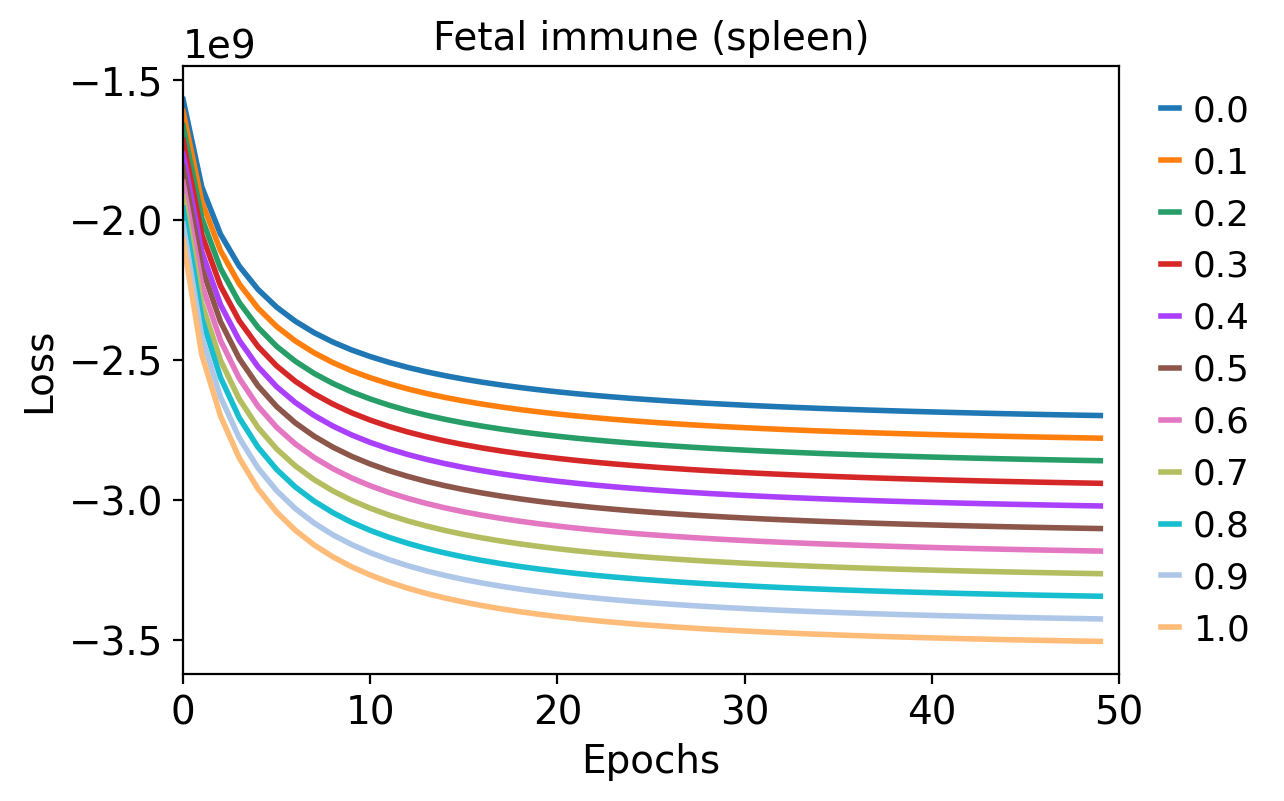

In [49]:
# define hyperparameters
learning_rate = 1e-6
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
for zmft_scalar in np.arange(0, 1+.1, .1):
    zmft_scalar = round(zmft_scalar, 1)
    # instantiate models on cpu
    model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # initialize the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model1.set_g2g(torch.from_numpy(input_g2g))
    model1.set_g2g_intra(torch.from_numpy(input_g2g))
    model1.to('cpu')
    # train the models
    losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
    # create the plot for spleen
    ax.plot(losses1, lw=2, label=zmft_scalar)
ax.set_xlim(0, 50)
vmin, vmax = ax.get_ylim()
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')
ax.legend(bbox_to_anchor=(1.01, .5), bbox_transform=ax.transAxes, frameon=False, loc='center left')

100%|███████████████████████████████████████████| 50/50 [00:07<00:00,  6.79it/s]


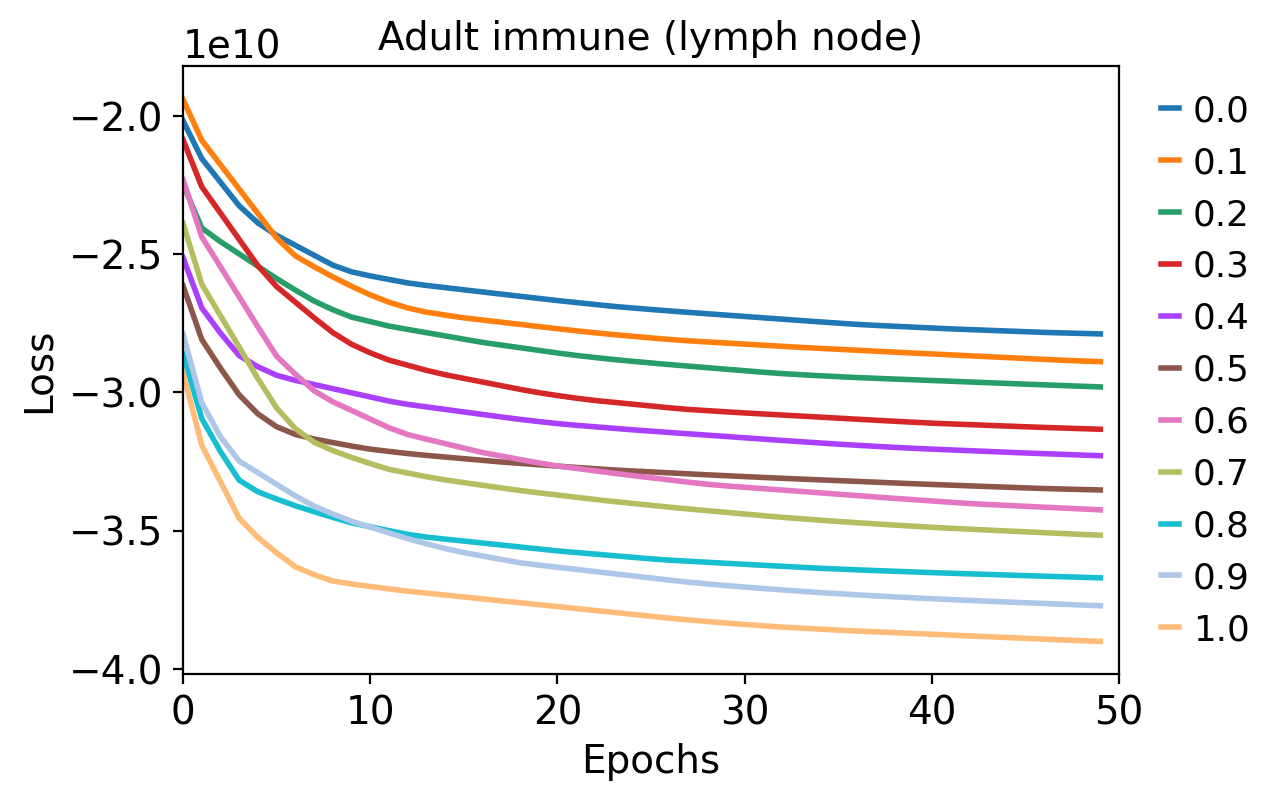

In [50]:
# define hyperparameters
learning_rate = 1e-10
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
for zmft_scalar in np.arange(0, 1+.1, .1):
    zmft_scalar = round(zmft_scalar, 1)
    # instantiate models on cpu
    model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # initialize the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model2.set_g2g(torch.from_numpy(input_g2g))
    model2.set_g2g_intra(torch.from_numpy(input_g2g))
    model2.to('cpu')
    # train the models
    losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
    # create the plot for spleen
    ax.plot(losses2, lw=2, label=zmft_scalar)
ax.set_xlim(0, 50)
vmin, vmax = ax.get_ylim()
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')
ax.legend(bbox_to_anchor=(1.01, .5), bbox_transform=ax.transAxes, frameon=False, loc='center left')

100%|█████████████████████████████████████████| 100/100 [00:29<00:00,  3.38it/s]


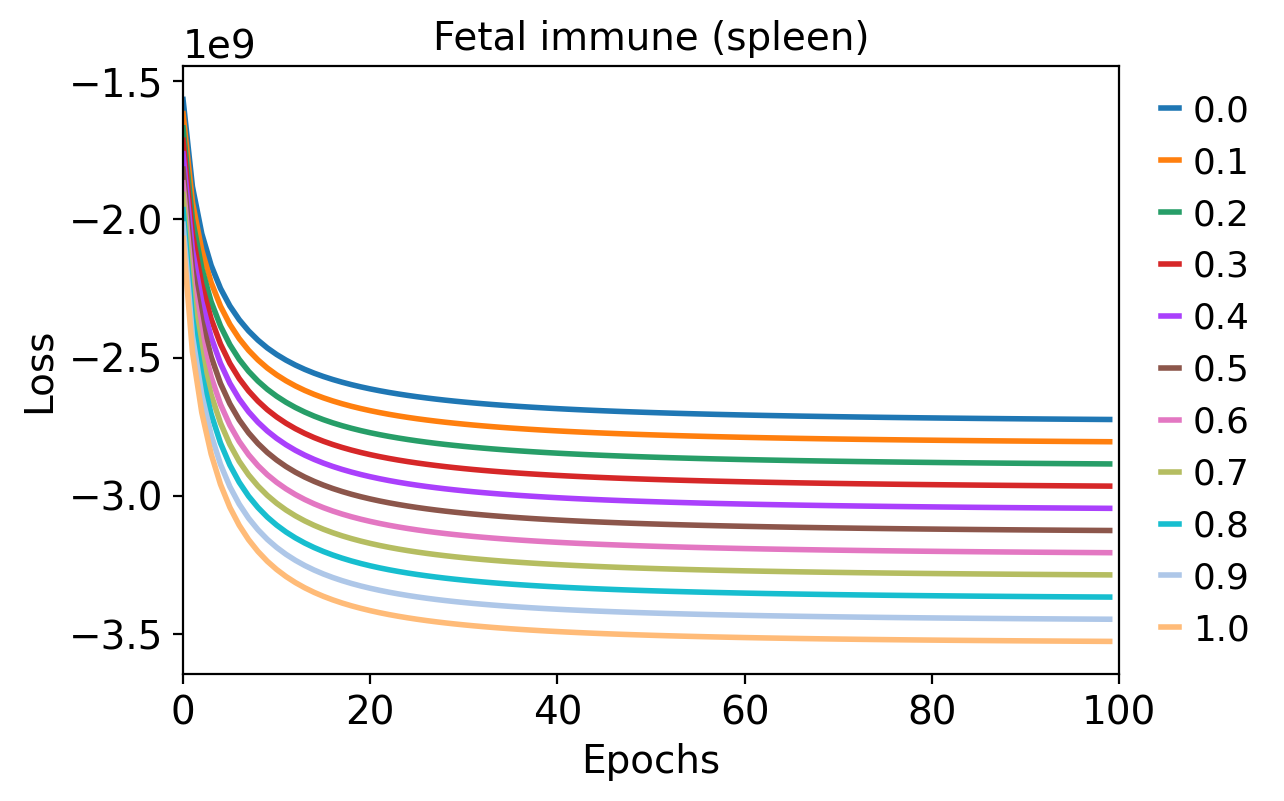

In [51]:
# define hyperparameters
learning_rate = 1e-6
epochs = 100
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
for zmft_scalar in np.arange(0, 1+.1, .1):
    zmft_scalar = round(zmft_scalar, 1)
    # instantiate models on cpu
    model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # initialize the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model1.set_g2g(torch.from_numpy(input_g2g))
    model1.set_g2g_intra(torch.from_numpy(input_g2g))
    model1.to('cpu')
    # train the models
    losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
    # create the plot for spleen
    ax.plot(losses1, lw=2, label=zmft_scalar)
ax.set_xlim(0, 100)
vmin, vmax = ax.get_ylim()
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')
ax.legend(bbox_to_anchor=(1.01, .5), bbox_transform=ax.transAxes, frameon=False, loc='center left')

100%|█████████████████████████████████████████| 100/100 [00:14<00:00,  6.76it/s]


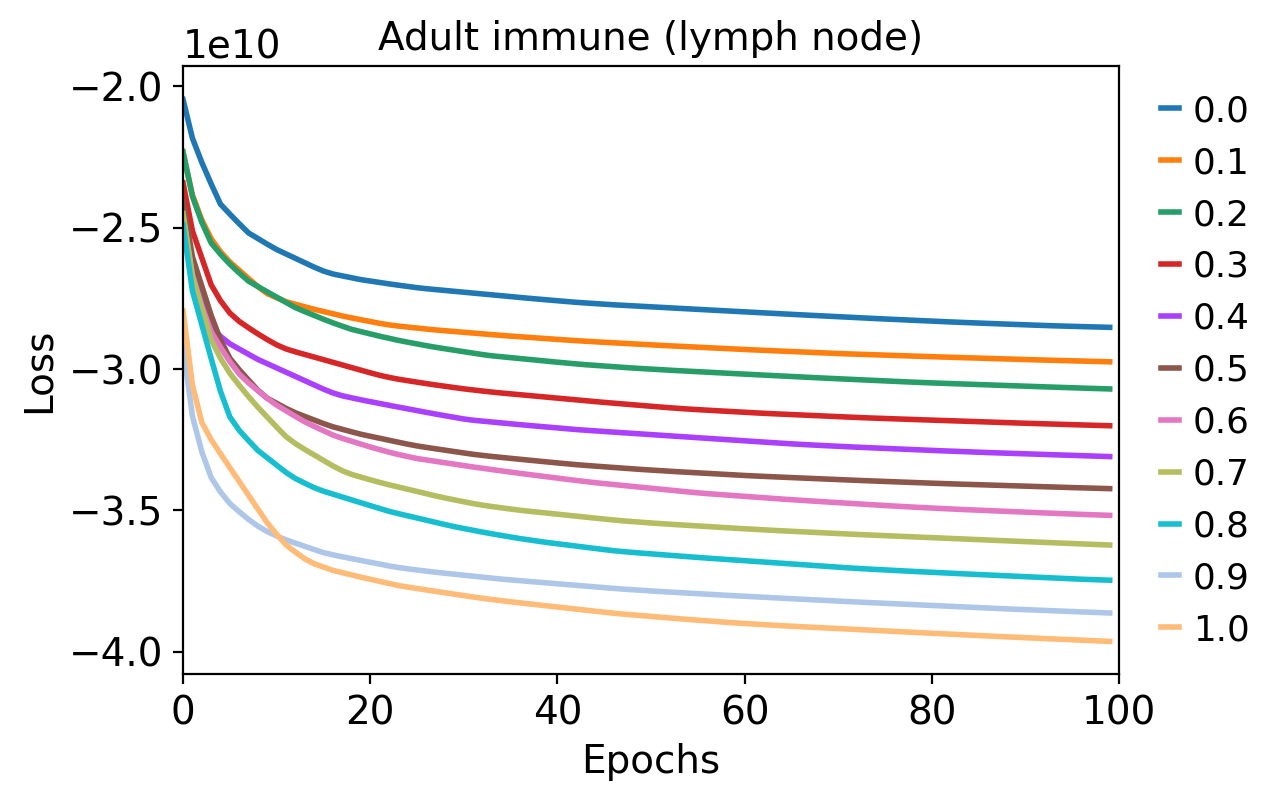

In [53]:
# define hyperparameters
learning_rate = 1e-10
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
for zmft_scalar in np.arange(0, 1+.1, .1):
    zmft_scalar = round(zmft_scalar, 1)
    # instantiate models on cpu
    model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # initialize the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model2.set_g2g(torch.from_numpy(input_g2g))
    model2.set_g2g_intra(torch.from_numpy(input_g2g))
    model2.to('cpu')
    # train the models
    losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
    # create the plot for spleen
    ax.plot(losses2, lw=2, label=zmft_scalar)
ax.set_xlim(0, 100)
vmin, vmax = ax.get_ylim()
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')
ax.legend(bbox_to_anchor=(1.01, .5), bbox_transform=ax.transAxes, frameon=False, loc='center left')

The stable optimization of Celcomen indicates that zmft_scalar has been chosen appropriately.

(-1.0, 1.0)

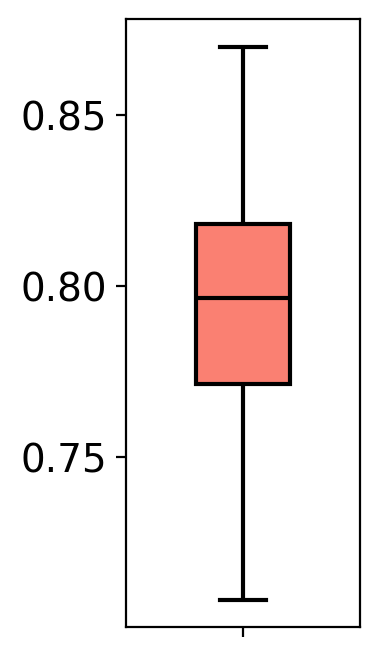

In [68]:
# get an estimate of the true percentage of drop outs
drop_outs = []
for x in loader1:
    drop_outs.append(np.mean((x.x == 0).detach().numpy()))
fig, ax = plt.subplots(figsize=[1.5, 4]); ax.grid(False)
sns.boxplot(drop_outs, ax=ax, linewidth=1.5, linecolor='k', saturation=1, color='salmon')
ax.set_xlim(-1, 1)

(-1.0, 1.0)

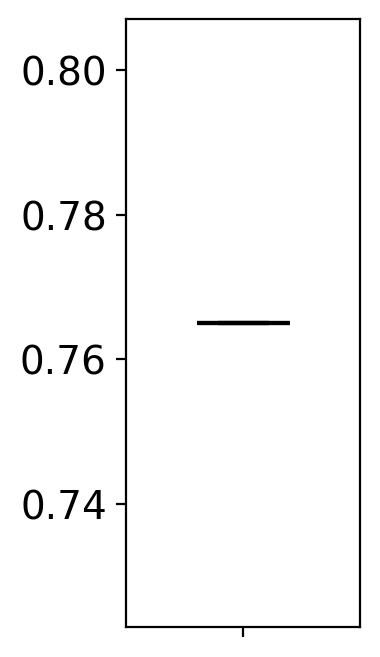

In [69]:
# get an estimate of the true percentage of drop outs
drop_outs = []
for x in loader2:
    drop_outs.append(np.mean((x.x == 0).detach().numpy()))
fig, ax = plt.subplots(figsize=[1.5, 4]); ax.grid(False)
sns.boxplot(drop_outs, ax=ax, linewidth=1.5, linecolor='k', saturation=1, color='salmon')
ax.set_xlim(-1, 1)